# SVM Microglia Detection — Refactored

Refactored from `SVM_original_fixed.ipynb` with emphasis on:
- **Modularity**: functions grouped by responsibility, each cell does one thing
- **Readability**: all magic numbers moved to `Config`, consistent naming
- **Hyperparameter Tuning**: `GridSearchCV` over key SVM and feature parameters

### Pipeline overview
```
Source images
  └─ [1] Preprocessing  → Microglia / Noise patches
  └─ [2] Feature extraction (HOG + colour)
  └─ [3] Hyperparameter search (GridSearchCV)
  └─ [4] Train LinearSVC with best params
  └─ [5] Evaluate (accuracy, precision, recall, F1)
  └─ [6] Threshold analysis (F1 vs decision threshold)
  └─ [7] Detection on test images (image pyramid → sliding window → cross-scale NMS → bboxes)
  └─ [8] Evaluation against ground truth (IoU matching → precision / recall)
```

## 1  Imports

In [1]:
import os
import csv
import shutil
import time
from dataclasses import dataclass

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from skimage.feature import hog, local_binary_pattern

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_recall_fscore_support

%matplotlib inline

## 2  Configuration

**All tunable values live here.** Change anything in `Config` and the rest of the notebook
picks it up automatically — no hunting for magic numbers in function bodies.

In [ ]:
INPUT_DIR = ".."
WORK_DIR  = "."
ARTIFACT_DIR  = "./microglia-artifacts-original"


@dataclass
class Config:
    # ── Paths — inputs ─────────────────────────────────────────────────────
    image_rois_csv: str = f"{INPUT_DIR}/Image_ROIs.csv"
    source_images:  str = f"{INPUT_DIR}/Source_images"
    test_dir:       str = f"{INPUT_DIR}/test_images"

    # ── Paths — outputs ────────────────────────────────────────────────────
    microglia_folder:      str = f"{WORK_DIR}/Processed_training_images/Train/Microglia"
    noise_folder:          str = f"{WORK_DIR}/Processed_training_images/Train/Noise"
    microglia_val_folder:  str = f"{WORK_DIR}/Processed_training_images/Validate/Microglia"
    noise_val_folder:      str = f"{WORK_DIR}/Processed_training_images/Validate/Noise"
    microglia_test_folder: str = f"{WORK_DIR}/Processed_training_images/Test/Microglia"
    noise_test_folder:     str = f"{WORK_DIR}/Processed_training_images/Test/Noise"
    hnm_folder:            str = f"{WORK_DIR}/Processed_training_images/HardNegatives"

    features_cache:        str = f"{ARTIFACT_DIR}/features_cache.npz"
    val_paths_cache:       str = f"{ARTIFACT_DIR}/val_paths.txt"
    svm_clf_path:          str = f"{ARTIFACT_DIR}/svm_clf.pkl"
    scaler_path:           str = f"{ARTIFACT_DIR}/scaler.pkl"
    pca_path:              str = f"{ARTIFACT_DIR}/pca.pkl"
    hnm_train_final:       str = f"{ARTIFACT_DIR}/hnm_train_final.npz"

    # ── Preprocessing ──────────────────────────────────────────────────────
    image_size:   int = 2048
    window_size:  int = 64

    # ── Feature extraction ─────────────────────────────────────────────────
    color_conv:            str   = 'BGR2HSV'
    hog_channel:           str   = 'ALL'
    hog_orient:            int   = 9
    hog_pix_per_cell:      int   = 8
    hog_pix_per_cell_fine: int   = 4
    hog_cell_per_block:    int   = 2
    spatial_size:          tuple = (32, 32)
    hist_bins:             int   = 32
    lbp_radius:    int = 2
    lbp_n_points:  int = 16
    lbp_n_bins:    int = 32

    # ── Dimensionality reduction ────────────────────────────────────────────
    pca_n_components: int = 4677   # 90% explained variance (variance curve 2026-05-22)

    # ── Train / validate split (source images only) ────────────────────────
    val_size:     float = 0.2
    random_state: int   = 42

    # ── SVM defaults (overridden by GridSearchCV best params) ──────────────
    svm_C:        float = 1.0
    svm_max_iter: int   = 10000

    # ── Detection ──────────────────────────────────────────────────────────
    cells_per_step:      int   = 2
    detection_threshold: float = 1.5
    scale_factors:  tuple = (0.75, 1.0, 1.5)
    nms_iou_thresh: float = 0.3


cfg = Config()
print(cfg)

Config(image_rois_csv='../Image_ROIs.csv', source_images='../Source_images', test_dir='../test_images', microglia_folder='./Processed_training_images/Train/Microglia', noise_folder='./Processed_training_images/Train/Noise', microglia_val_folder='./Processed_training_images/Validate/Microglia', noise_val_folder='./Processed_training_images/Validate/Noise', microglia_test_folder='./Processed_training_images/Test/Microglia', noise_test_folder='./Processed_training_images/Test/Noise', hnm_folder='./Processed_training_images/HardNegatives', features_cache='./microglia-artifacts/features_cache.npz', val_paths_cache='./microglia-artifacts/val_paths.txt', svm_clf_path='./microglia-artifacts/svm_clf.pkl', scaler_path='./microglia-artifacts/scaler.pkl', pca_path='./microglia-artifacts/pca.pkl', hnm_train_final='./microglia-artifacts/hnm_train_final.npz', image_size=2048, window_size=64, color_conv='BGR2HSV', hog_channel='ALL', hog_orient=9, hog_pix_per_cell=8, hog_pix_per_cell_fine=4, hog_cell_p

## 3  I/O Utilities

Low-level helpers for file-system operations and CSV parsing.

In [3]:
# ── Colour-space lookup ────────────────────────────────────────────────────
_COLOR_CODE = {
    'RGB2GRAY': cv2.COLOR_RGB2GRAY, 'RGB2RGBA': cv2.COLOR_RGB2RGBA,
    'RGB2BGR':  cv2.COLOR_RGB2BGR,  'RGB2BGRA': cv2.COLOR_RGB2BGRA,
    'RGB2HSV':  cv2.COLOR_RGB2HSV,  'RGB2HLS':  cv2.COLOR_RGB2HLS,
    'RGB2LUV':  cv2.COLOR_RGB2LUV,  'RGB2YUV':  cv2.COLOR_RGB2YUV,
    'RGB2YCrCb':cv2.COLOR_RGB2YCrCb,
    'BGR2GRAY': cv2.COLOR_BGR2GRAY, 'BGR2BGRA': cv2.COLOR_BGR2BGRA,
    'BGR2RGB':  cv2.COLOR_BGR2RGB,  'BGR2RGBA': cv2.COLOR_BGR2RGBA,
    'BGR2HSV':  cv2.COLOR_BGR2HSV,  'BGR2HLS':  cv2.COLOR_BGR2HLS,
    'BGR2LUV':  cv2.COLOR_BGR2LUV,  'BGR2YUV':  cv2.COLOR_BGR2YUV,
    'BGR2YCrCb':cv2.COLOR_BGR2YCrCb,
}


def convert_color(img: np.ndarray, conv_code: str) -> np.ndarray:
    """Convert *img* to the colour space named by *conv_code*."""
    return cv2.cvtColor(img, _COLOR_CODE[conv_code])


def clear_folder(folder_path: str) -> None:
    """Delete all contents of *folder_path*, creating it if absent."""
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        return
    for name in os.listdir(folder_path):
        entry = os.path.join(folder_path, name)
        shutil.rmtree(entry) if os.path.isdir(entry) else os.remove(entry)


def save_patch(img: np.ndarray, folder: str, filename: str) -> None:
    """Write *img* as JPEG to *folder/filename*."""
    os.makedirs(folder, exist_ok=True)
    cv2.imwrite(os.path.join(folder, filename), img)


def load_rois_for_image(image_name: str, csv_path: str) -> dict:
    """
    Return a dict of bounding-box dicts for *image_name* from the ROI CSV.

    Each value has keys: cx, cy, w, h (all strings; cast on use).
    Returns an empty dict on any error.
    """
    rois, count = {}, 0
    try:
        with open(csv_path, newline='') as fh:
            for row in csv.reader(fh):
                if len(row) > 5 and row[5] == image_name + ".png" and row[0] == "0":
                    rois[count] = {"x": row[1], "y": row[2], "w": row[3], "h": row[4]}
                    count += 1
    except FileNotFoundError:
        print(f"Warning: CSV not found — {csv_path}")
    except Exception as exc:
        print(f"Warning: could not read CSV — {exc}")
    return rois


def list_images(folder: str) -> list:
    """Return sorted list of image paths in *folder*."""
    exts = ('.jpg', '.jpeg', '.png')
    return sorted(
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(exts)
    )


def plot_image(img: np.ndarray, title: str = "", show: bool = True) -> None:
    """Display *img* with an optional *title* when *show* is True."""
    if not show:
        return
    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

## 4  Image Processing

Patch cropping, masking, and rotation augmentation.

In [4]:
def _clamp_crop(start: int, size: int, window: int):
    """Clamp start so a window of *window* pixels stays inside [0, size]."""
    start = max(0, start)
    end   = start + window
    if end > size:
        end   = size
        start = max(0, end - window)
    return start, end


def crop_centered(img: np.ndarray, bbox: dict, window_size: int, image_size: int) -> np.ndarray:
    """
    Crop a *window_size* × *window_size* patch centred on the bounding-box centre.

    *bbox* must have keys x, y (top-left coords) and w, h (dimensions).
    Centre is (x + w//2, y + h//2).
    """
    x  = int(float(bbox["x"]))
    y  = int(float(bbox["y"]))
    w  = int(float(bbox["w"]))
    h  = int(float(bbox["h"]))
    cx = x + w // 2
    cy = y + h // 2
    half = window_size // 2
    ystart, yend = _clamp_crop(cy - half, image_size, window_size)
    xstart, xend = _clamp_crop(cx - half, image_size, window_size)
    return img[ystart:yend, xstart:xend]


def crop_grid(img: np.ndarray, col: int, row: int, window_size: int, image_size: int) -> np.ndarray:
    """Crop patch at grid position (*col*, *row*) in pixel space."""
    ystart, yend = _clamp_crop(row, image_size, window_size)
    xstart, xend = _clamp_crop(col, image_size, window_size)
    return img[ystart:yend, xstart:xend]


def build_inv_mask(bbox: dict, mask: np.ndarray) -> np.ndarray:
    """
    Fill the microglia bounding box on *mask* (in-place) so it can later be
    inverted to sample noise-only regions.

    bbox keys x, y are the top-left corner; w, h are the full dimensions.
    Bottom-right corner is (x+w, y+h).
    """
    x = int(float(bbox["x"]))
    y = int(float(bbox["y"]))
    w = int(float(bbox["w"]))
    h = int(float(bbox["h"]))
    cv2.rectangle(mask, (x, y), (x + w, y + h), 255, -1)
    return mask


def save_augmented_patches(patch: np.ndarray, folder: str, stem: str, idx: int) -> None:
    """
    Save 8 augmented variants of a microglia patch: 4 rotations × 2 flip states.

    Generates:  0°, 90°, 180°, 270°,
                h-flip, h-flip+90°, h-flip+180°, h-flip+270°

    Using both rotation and reflection augmentation on the scarce positive class
    is important given only ~200 labelled cells across 13 training images.
    """
    rotations = [
        patch,
        cv2.rotate(patch, cv2.ROTATE_90_CLOCKWISE),
        cv2.rotate(patch, cv2.ROTATE_180),
        cv2.rotate(patch, cv2.ROTATE_90_COUNTERCLOCKWISE),
    ]
    # Horizontal flip of each rotation gives 4 additional distinct orientations
    flipped      = [cv2.flip(r, 1) for r in rotations]
    all_variants = rotations + flipped

    for i, variant in enumerate(all_variants):
        save_patch(variant, folder, f"{stem}{idx}_a{i}.jpg")

## 5  Preprocessing Pipeline

Extract labelled microglia patches and grid-sampled noise patches from each source image.

In [ ]:
def extract_patches_from_image(
   img_path: str,
   microglia_folder: str,
   noise_folder: str,
   cfg: Config,
   augment: bool = True,
   show_annotations: bool = False,
) -> None:
   """
   Extract positive (microglia) and negative (noise) patches from one source image.

   augment=True  (train): microglia saved with 8-way augmentation.
   augment=False (val/test): single patch per cell, no augmentation.
   """
   img = cv2.imread(img_path)
   if img is None:
       print(f"Warning: could not read {img_path}")
       return

   stem = os.path.splitext(os.path.basename(img_path))[0]
   rois = load_rois_for_image(stem, cfg.image_rois_csv)
   mask = np.zeros(img.shape[:2], dtype=np.uint8)

   for idx, bbox in rois.items():
       mask  = build_inv_mask(bbox, mask)
       patch = crop_centered(img, bbox, cfg.window_size, cfg.image_size)
       if augment:
           save_augmented_patches(patch, microglia_folder, stem, idx)
       else:
           save_patch(patch, microglia_folder, f"{stem}{idx}.jpg")

   bg_img  = cv2.bitwise_and(img, img, mask=cv2.bitwise_not(mask))
   n_steps = (cfg.image_size // cfg.window_size) - 1

   noise_idx = 0
   for col_i in range(n_steps):
       for row_i in range(n_steps):
           patch = crop_grid(
               bg_img,
               col_i * cfg.window_size,
               row_i * cfg.window_size,
               cfg.window_size,
               cfg.image_size,
           )
           save_patch(patch, noise_folder, f"{stem}{noise_idx}.jpg")
           noise_idx += 1

   if show_annotations:
       vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
       for bbox in rois.values():
           x = int(float(bbox["x"]));  y = int(float(bbox["y"]))
           w = int(float(bbox["w"]));  h = int(float(bbox["h"]))
           cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 4)
       plot_image(vis,  title=f"GT annotations — {stem} ({len(rois)} cells)")
       plot_image(mask, title=f"Microglia mask — {stem}")


def preprocess_all_images(cfg: Config, show_annotations: bool = False) -> tuple:
   """
   Build patch datasets for train, validate, and test splits.

   Train / Validate: split from Source_images/ at the image level (before augmentation).
   Test: patches extracted from the fixed images in test_dir/ (never in train or val).

   Returns
   -------
   train_paths, val_paths : source image paths for each split.
   These are stored so the HNM loop can run full-image detection on val images.
   """
   for folder in (
       cfg.microglia_folder,     cfg.noise_folder,
       cfg.microglia_val_folder, cfg.noise_val_folder,
       cfg.microglia_test_folder, cfg.noise_test_folder,
   ):
       clear_folder(folder)

   source_paths = list_images(cfg.source_images)
   train_paths, val_paths = train_test_split(
       source_paths, test_size=cfg.val_size, random_state=cfg.random_state
   )
   test_image_paths = list_images(cfg.test_dir)

   print(f"Source images — train: {len(train_paths)}, val: {len(val_paths)}")
   print(f"Test images   — fixed: {len(test_image_paths)}\n")

   print("── Train images (augmented) ──")
   for i, path in enumerate(train_paths, 1):
       print(f"[{i}/{len(train_paths)}] {os.path.basename(path)}")
       extract_patches_from_image(
           path, cfg.microglia_folder, cfg.noise_folder,
           cfg, augment=True, show_annotations=show_annotations,
       )

   print("\n── Validate images (no augmentation) ──")
   for i, path in enumerate(val_paths, 1):
       print(f"[{i}/{len(val_paths)}] {os.path.basename(path)}")
       extract_patches_from_image(
           path, cfg.microglia_val_folder, cfg.noise_val_folder,
           cfg, augment=False, show_annotations=show_annotations,
       )

   print("\n── Test images (no augmentation, fixed held-out set) ──")
   for i, path in enumerate(test_image_paths, 1):
       print(f"[{i}/{len(test_image_paths)}] {os.path.basename(path)}")
       extract_patches_from_image(
           path, cfg.microglia_test_folder, cfg.noise_test_folder,
           cfg, augment=False, show_annotations=show_annotations,
       )

   train_pos = len(list_images(cfg.microglia_folder))
   train_neg = len(list_images(cfg.noise_folder))
   val_pos   = len(list_images(cfg.microglia_val_folder))
   val_neg   = len(list_images(cfg.noise_val_folder))
   test_pos  = len(list_images(cfg.microglia_test_folder))
   test_neg  = len(list_images(cfg.noise_test_folder))
   print(f"\nTrain    — microglia: {train_pos}, noise: {train_neg}  "
         f"(ratio: {train_neg / max(1, train_pos):.1f}:1)")
   print(f"Validate — microglia: {val_pos},  noise: {val_neg}  "
         f"(ratio: {val_neg / max(1, val_pos):.1f}:1)")
   print(f"Test     — microglia: {test_pos},  noise: {test_neg}  "
         f"(ratio: {test_neg / max(1, test_pos):.1f}:1)")

   return train_paths, val_paths
#
#
## Uncomment to run (slow — only needed when source data changes).
train_paths, val_paths = preprocess_all_images(cfg, show_annotations=False)
#
## Save only filenames (not full paths) so the cache is portable across machines.
val_stems = [os.path.basename(p) for p in val_paths]
with open(cfg.val_paths_cache, "w") as f:
   f.write("\n".join(val_stems))
print(f"val_paths saved to {cfg.val_paths_cache}")

## 6  Feature Extraction

Five feature types are concatenated into a single vector per patch:

1. **Spatial bins** — resized per-channel pixel values (captures colour layout)
2. **Colour histogram** — per-channel histogram (captures colour distribution)
3. **LBP** — Local Binary Patterns on grayscale (captures fine-grained cell texture)
4. **Intensity statistics** — per-channel mean, std, skewness (captures staining profile)
5. **Multi-scale HOG** — gradient orientations at `pix_per_cell=4` (fine) and `pix_per_cell=8` (coarse), covering both thin microglia processes and the larger soma

In [6]:
def bin_spatial(img: np.ndarray, size: tuple) -> np.ndarray:
    """Flatten resized per-channel pixel values into a 1-D vector."""
    return np.hstack([
        cv2.resize(img[:, :, ch], size).ravel()
        for ch in range(img.shape[2])
    ])


def color_hist(img: np.ndarray, nbins: int) -> np.ndarray:
    """Concatenated per-channel colour histogram."""
    return np.concatenate([
        np.histogram(img[:, :, ch], bins=nbins)[0]
        for ch in range(img.shape[2])
    ])


def lbp_features(img_gray: np.ndarray, radius: int, n_points: int, n_bins: int) -> np.ndarray:
    """
    Normalised LBP histogram for a single-channel (grayscale) image.

    Uses 'uniform' LBP which reduces the descriptor to n_points + 2 patterns
    that are rotation-invariant and robust to monotonic intensity changes.
    """
    lbp  = local_binary_pattern(img_gray, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_points + 2), density=True)
    return hist


def intensity_stats(img: np.ndarray) -> np.ndarray:
    """Per-channel mean, standard deviation, and skewness."""
    stats = []
    for ch in range(img.shape[2]):
        ch_vals = img[:, :, ch].ravel().astype(np.float32)
        mean    = ch_vals.mean()
        std     = ch_vals.std() + 1e-6
        skew    = np.mean(((ch_vals - mean) / std) ** 3)
        stats.extend([mean, std, skew])
    return np.array(stats)


def _hog_for_channels(img: np.ndarray, orient: int, ppc: int, cpb: int,
                       hog_channel: str) -> np.ndarray:
    """Compute HOG and flatten across the requested channels."""
    if hog_channel == 'ALL':
        return np.ravel([
            hog(img[:, :, ch], orientations=orient,
                pixels_per_cell=(ppc, ppc), cells_per_block=(cpb, cpb),
                transform_sqrt=True, feature_vector=True)
            for ch in range(img.shape[2])
        ])
    ch = int(hog_channel)
    return hog(img[:, :, ch], orientations=orient,
               pixels_per_cell=(ppc, ppc), cells_per_block=(cpb, cpb),
               transform_sqrt=True, feature_vector=True)


def hog_features(
    img: np.ndarray,
    orient: int,
    pix_per_cell: int,
    cell_per_block: int,
    feature_vector: bool = True,
) -> np.ndarray:
    """HOG features for a single-channel image (used by the detection pipeline)."""
    return hog(
        img,
        orientations=orient,
        pixels_per_cell=(pix_per_cell, pix_per_cell),
        cells_per_block=(cell_per_block, cell_per_block),
        transform_sqrt=True,
        feature_vector=feature_vector,
    )


def extract_features(image_paths: list, cfg: Config, label: str = "") -> list:
    """
    Extract and concatenate all five feature types for each image path.

    Feature vector layout (in order):
        [spatial_bins | color_hist | lbp | intensity_stats | hog_fine | hog_coarse]

    The same order must be preserved in the detection pipeline so that the
    scaler and classifier see identical feature layouts at inference time.
    """
    features    = []
    n           = len(image_paths)
    prefix      = f"  [{label}] " if label else "  "
    report_step = max(1, n // 10)

    for i, path in enumerate(image_paths):
        if i % report_step == 0:
            print(f"{prefix}{i}/{n} ({100 * i // n:3d}%)", end="\r", flush=True)
        try:
            raw      = mpimg.imread(path)
            img      = convert_color(raw, cfg.color_conv)
            img_gray = cv2.cvtColor(raw, cv2.COLOR_RGB2GRAY)

            spatial    = bin_spatial(img, cfg.spatial_size)
            chist      = color_hist(img, cfg.hist_bins)
            lbp_feat   = lbp_features(img_gray, cfg.lbp_radius,
                                       cfg.lbp_n_points, cfg.lbp_n_bins)
            int_stats  = intensity_stats(img)
            hog_fine   = _hog_for_channels(img, cfg.hog_orient,
                                            cfg.hog_pix_per_cell_fine,
                                            cfg.hog_cell_per_block, cfg.hog_channel)
            hog_coarse = _hog_for_channels(img, cfg.hog_orient,
                                            cfg.hog_pix_per_cell,
                                            cfg.hog_cell_per_block, cfg.hog_channel)

            features.append(np.concatenate((
                spatial, chist, lbp_feat, int_stats, hog_fine, hog_coarse
            )))
        except Exception as exc:
            print(f"\nSkipping {path}: {exc}")

    print(f"{prefix}{n}/{n} (100%) — {n} feature vectors extracted")
    return features

## 7  Dataset Setup

Load patches from the pre-split Train / Validate / Test folders, extract features,
scale, and apply PCA.

- **Train / Validate** patches come from `Source_images/` split at the image level in `preprocess_all_images`.
- **Test** patches come from the fixed `test_dir/` images, extracted separately.
- Scaler and PCA are fit on training data only, then applied to validate and test.

In [ ]:
def extract_raw_features(cfg: Config):
    """
    Extract raw (unscaled) feature vectors from train and validate patch folders.
    Called once at startup — this is the slow step.
    Returns arrays that can be incrementally extended during HNM without re-extraction.
    """
    train_pos_paths = list_images(cfg.microglia_folder)
    train_neg_paths = list_images(cfg.noise_folder)
    val_pos_paths   = list_images(cfg.microglia_val_folder)
    val_neg_paths   = list_images(cfg.noise_val_folder)

    print(f"Train    — microglia: {len(train_pos_paths)}, noise: {len(train_neg_paths)}")
    print(f"Validate — microglia: {len(val_pos_paths)},  noise: {len(val_neg_paths)}")

    print("\nExtracting train features...")
    train_pos_feats = extract_features(train_pos_paths, cfg, label="train microglia")
    train_neg_feats = extract_features(train_neg_paths, cfg, label="train noise")

    print("Extracting validate features...")
    val_pos_feats   = extract_features(val_pos_paths, cfg, label="val microglia")
    val_neg_feats   = extract_features(val_neg_paths, cfg, label="val noise")

    X_train_raw = np.vstack((train_pos_feats, train_neg_feats)).astype(np.float32)
    y_train_raw = np.hstack((np.ones(len(train_pos_feats)), np.zeros(len(train_neg_feats))))
    X_val_raw   = np.vstack((val_pos_feats, val_neg_feats)).astype(np.float32)
    y_val_raw   = np.hstack((np.ones(len(val_pos_feats)), np.zeros(len(val_neg_feats))))

    print(f"\nRaw feature dim : {X_train_raw.shape[1]}")
    print(f"Train: {len(X_train_raw)} | Validate: {len(X_val_raw)}")
    return X_train_raw, X_val_raw, y_train_raw, y_val_raw


def fit_pipeline(X_train_raw: np.ndarray, X_val_raw: np.ndarray,
                 y_train_raw: np.ndarray, y_val_raw: np.ndarray, cfg: Config):
    """
    Fit scaler and PCA on X_train_raw, then transform train and val.
    Fast — no feature extraction. Called once on the base training set; the
    scaler + PCA it fits are then held fixed through hard-negative mining.
    """
    scaler  = StandardScaler().fit(X_train_raw)
    X_train = scaler.transform(X_train_raw)
    X_val   = scaler.transform(X_val_raw)

    pca = None
    if cfg.pca_n_components > 0:
        n_components = cfg.pca_n_components
        if isinstance(n_components, int) or n_components >= 1:
            n_components = min(int(n_components), X_train.shape[1], X_train.shape[0])
        pca     = PCA(n_components=n_components, svd_solver='randomized', random_state=cfg.random_state, copy=False)
        X_train = pca.fit_transform(X_train)
        X_val   = pca.transform(X_val)

        var_retained = pca.explained_variance_ratio_.sum()
        print(f"PCA: {X_train_raw.shape[1]} → {pca.n_components_} components "
              f"({var_retained:.1%} variance retained)")

    print(f"Train: {len(X_train)} | Validate: {len(X_val)}")
    return X_train, X_val, y_train_raw, y_val_raw, scaler, pca


# # ── Initial feature extraction (once) ─────────────────────────────────────
X_train_raw, X_val_raw, y_train_raw, y_val_raw = extract_raw_features(cfg)

# # Save raw features so this step can be skipped on kernel restart.
np.savez_compressed(cfg.features_cache,
                    X_train_raw=X_train_raw, X_val_raw=X_val_raw,
                    y_train_raw=y_train_raw, y_val_raw=y_val_raw)
print(f"Features saved to {cfg.features_cache}")

# # To reload instead of re-extracting:
# #   cache = np.load(cfg.features_cache)
# #   X_train_raw, X_val_raw   = cache["X_train_raw"], cache["X_val_raw"]
# #   y_train_raw, y_val_raw   = cache["y_train_raw"], cache["y_val_raw"]

# # ── Fit scaler + PCA ───────────────────────────────────────────────────────
# X_train, X_val, y_train, y_val, scaler, pca = fit_pipeline(
#     X_train_raw, X_val_raw, y_train_raw, y_val_raw, cfg
# )

## 8  Hyperparameter Tuning

Grid-search over the regularisation parameter **C** using 5-fold stratified cross-validation
scored by **F1** (more informative than accuracy on this imbalanced dataset).

The best `C` is written back to `cfg.svm_C` so the training cell below uses it automatically.

In [8]:
def tune_svm(X_train: np.ndarray, y_train: np.ndarray, cfg: Config) -> dict:
    """
    Run GridSearchCV over LinearSVC(C) on the training set.

    Returns the best parameter dict and updates *cfg.svm_C* in place.
    """
    param_grid = {"C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

    # With negative-heavy training data (max_noise_ratio=10), 'balanced' would
    # up-weight positives ~10×, pushing the boundary to aggressively predict cells
    # and undoing the data fix. Use None (equal weights) so the model learns from
    # the actual distribution we constructed.
    base_clf = LinearSVC(
        max_iter=cfg.svm_max_iter,
        class_weight=None,
        dual=False,
        random_state=cfg.random_state,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.random_state)

    grid = GridSearchCV(
        estimator=base_clf,
        param_grid=param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=1,
        verbose=1,
    )
    grid.fit(X_train, y_train)

    results = grid.cv_results_
    print("\nC        mean-F1  std-F1")
    for c, mean, std in zip(
        param_grid["C"],
        results["mean_test_score"],
        results["std_test_score"],
    ):
        marker = " ← best" if c == grid.best_params_["C"] else ""
        print(f"{c:<8} {mean:.4f}   ±{std:.4f}{marker}")

    print(f"\nBest params : {grid.best_params_}")
    print(f"Best CV F1  : {grid.best_score_:.4f}")

    cfg.svm_C = grid.best_params_["C"]
    return grid.best_params_


# best_params = tune_svm(X_train, y_train, cfg)
# print(f"\ncfg.svm_C updated to: {cfg.svm_C}")

## 9  Model Training

Train a `LinearSVC` with the best `C` found in the grid search.

In [9]:
def train_svm(X_train: np.ndarray, y_train: np.ndarray, cfg: Config) -> LinearSVC:
    """Fit a LinearSVC and return the trained classifier."""
    clf = LinearSVC(
        C=cfg.svm_C,
        max_iter=cfg.svm_max_iter,
        class_weight=None,
        dual=False,
        random_state=cfg.random_state,
    )
    t0 = time.time()
    clf.fit(X_train, y_train)
    print(f"Training time : {time.time() - t0:.2f}s")
    return clf


# svm_clf = train_svm(X_train, y_train, cfg)

## 10  Model Evaluation

In [10]:
def evaluate_classifier(clf: LinearSVC, X: np.ndarray, y: np.ndarray, label: str = "") -> None:
    """Print accuracy, precision, recall, and F1 for a given split."""
    y_pred = clf.predict(X)
    acc    = (y_pred == y).mean()
    prec, rec, f1, _ = precision_recall_fscore_support(y, y_pred, average='binary')

    prefix = f"[{label}] " if label else ""
    print(f"{prefix}Accuracy  : {acc:.4f}")
    print(f"{prefix}Precision : {prec:.4f}")
    print(f"{prefix}Recall    : {rec:.4f}")
    print(f"{prefix}F1-Score  : {f1:.4f}")


# print("Validate patch-level metrics:")
# evaluate_classifier(svm_clf, X_val, y_val)

## 11  Threshold Tuning

Detection threshold is tuned **after** HNM using detection-level IoU metrics on the validate images.
Patch-level F1 is not used for threshold selection — it does not reflect inference-time class imbalance.

See Section 13 (Hard Negative Mining) for `tune_detection_threshold`.

## 12  Detection Pipeline

Three stages:
1. **`sliding_window_detect`** — sweep a (possibly rescaled) image, return scored detections using the SVM decision function
2. **`non_max_suppression`** — suppress lower-scoring overlapping boxes, keeping one box per cell
3. **`multi_scale_detect`** — build an image pyramid, run the detector at each scale, map boxes back to original coordinates, then apply cross-scale NMS

**Why an image pyramid instead of heatmap blobs?**
Microglia vary in size (roughly 25–100 px). Running the 64 px detector on a downscaled image lets it catch larger cells; running it on an upscaled image catches smaller ones. Cross-scale NMS then picks one best-fitting box per cell rather than merging overlapping detections into a single large blob.

In [11]:
# joblib.dump(svm_clf, cfg.svm_clf_path)
# joblib.dump(scaler,  cfg.scaler_path)
# joblib.dump(pca,     cfg.pca_path)
# print(f"Model saved to {WORK_DIR}/")

In [12]:
def sliding_window_detect(
    img: np.ndarray,
    clf: LinearSVC,
    scaler: StandardScaler,
    cfg: Config,
    pca: PCA = None,
    _batch_size: int = 512,
) -> tuple:
    """
    Sweep the image with a sliding window and return scored detections.

    Uses clf.decision_function (continuous score) rather than clf.predict so
    that NMS can rank overlapping boxes by confidence.

    Precomputes HOG maps, LBP map, and integral images for intensity stats
    before the loop. Scaler/PCA/classifier calls are batched to avoid
    per-window Python overhead.

    Returns
    -------
    detections : list of ((x0, y0), (x1, y1)) in pixel coordinates
    scores     : parallel list of SVM decision-function values
    """
    img_uint8 = img if img.dtype == np.uint8 else (img * 255).astype(np.uint8)
    # Color conversion on uint8 so value ranges match extract_features at training time.
    # OpenCV BGR2HSV on uint8 → H=[0,179], S/V=[0,255]; on float32 → H=[0,360], S/V=[0,1].
    img_c    = convert_color(img_uint8, cfg.color_conv)
    img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    ppc_c = cfg.hog_pix_per_cell
    ppc_f = cfg.hog_pix_per_cell_fine
    cpb   = cfg.hog_cell_per_block
    win   = cfg.window_size
    cps   = cfg.cells_per_step

    pixel_stride  = cps * ppc_c
    cps_f         = pixel_stride // ppc_f
    nblocks_win_c = (win // ppc_c) - (cpb - 1)
    nblocks_win_f = (win // ppc_f) - (cpb - 1)
    nxblocks_c    = (img_c.shape[1] // ppc_c) - 1
    nyblocks_c    = (img_c.shape[0] // ppc_c) - 1
    nxsteps       = (nxblocks_c - nblocks_win_c) // cps
    nysteps       = (nyblocks_c - nblocks_win_c) // cps
    n_ch          = img_c.shape[2]

    hog_maps_c = [
        hog_features(img_c[:, :, ch], cfg.hog_orient, ppc_c, cpb, feature_vector=False)
        for ch in range(n_ch)
    ]
    hog_maps_f = [
        hog_features(img_c[:, :, ch], cfg.hog_orient, ppc_f, cpb, feature_vector=False)
        for ch in range(n_ch)
    ]

    lbp_map = local_binary_pattern(
        img_gray.astype(np.float64), cfg.lbp_n_points, cfg.lbp_radius, method='uniform'
    )

    integ_sum, integ_sq, integ_cu = [], [], []
    for ch in range(n_ch):
        ch_f = img_c[:, :, ch].astype(np.float64)
        integ_sum.append(cv2.integral(ch_f))
        integ_sq.append(cv2.integral(ch_f * ch_f))
        integ_cu.append(cv2.integral(ch_f * ch_f * ch_f))

    def _query(integ, y0, x0, y1, x1):
        return integ[y1, x1] - integ[y0, x1] - integ[y1, x0] + integ[y0, x0]

    def _intensity_stats_fast(ytop, xleft):
        n = win * win
        stats = []
        for ch in range(n_ch):
            s1 = _query(integ_sum[ch], ytop, xleft, ytop + win, xleft + win)
            s2 = _query(integ_sq[ch],  ytop, xleft, ytop + win, xleft + win)
            s3 = _query(integ_cu[ch],  ytop, xleft, ytop + win, xleft + win)
            mean = s1 / n
            var  = max(s2 / n - mean * mean, 0.0)
            std  = var ** 0.5 + 1e-6
            skew = (s3 / n - 3 * mean * (s2 / n) + 2 * mean ** 3) / (std ** 3)
            stats.extend([mean, std, skew])
        return np.array(stats, dtype=np.float32)

    detections, det_scores = [], []
    batch_feats, batch_pos = [], []
    report_every = max(1, nxsteps // 10)

    def _flush():
        if not batch_feats:
            return
        X = np.array(batch_feats, dtype=np.float32)
        X = scaler.transform(X)
        if pca is not None:
            X = pca.transform(X)
        for (xleft, ytop), score in zip(batch_pos, clf.decision_function(X)):
            if score > cfg.detection_threshold:
                detections.append(((xleft, ytop), (xleft + win, ytop + win)))
                det_scores.append(float(score))
        batch_feats.clear()
        batch_pos.clear()

    for xb in range(nxsteps):
        if xb % report_every == 0:
            print(f"    {100 * xb // nxsteps:3d}%", end=" ", flush=True)
        for yb in range(nysteps):
            xpos_c, ypos_c = xb * cps,   yb * cps
            xpos_f, ypos_f = xb * cps_f, yb * cps_f
            xleft = xpos_c * ppc_c
            ytop  = ypos_c * ppc_c

            hog_coarse = np.hstack([
                hm[ypos_c:ypos_c + nblocks_win_c,
                   xpos_c:xpos_c + nblocks_win_c].ravel()
                for hm in hog_maps_c
            ])
            hog_fine = np.hstack([
                hm[ypos_f:ypos_f + nblocks_win_f,
                   xpos_f:xpos_f + nblocks_win_f].ravel()
                for hm in hog_maps_f
            ])

            lbp_feat = np.histogram(
                lbp_map[ytop:ytop + win, xleft:xleft + win],
                bins=cfg.lbp_n_bins, range=(0, cfg.lbp_n_points + 2), density=True,
            )[0].astype(np.float32)

            int_stats = _intensity_stats_fast(ytop, xleft)

            sub     = img_c[ytop:ytop + win, xleft:xleft + win]
            spatial = bin_spatial(sub, cfg.spatial_size)
            chist   = color_hist(sub, cfg.hist_bins)

            batch_feats.append(np.hstack((spatial, chist, lbp_feat, int_stats, hog_fine, hog_coarse)))
            batch_pos.append((xleft, ytop))

            if len(batch_feats) >= _batch_size:
                _flush()

    _flush()
    print("100%")
    return detections, det_scores


def non_max_suppression(detections: list, scores: list, iou_thresh: float) -> list:
    """Greedy score-ordered NMS — suppress boxes with IoU > iou_thresh."""
    if not detections:
        return []
    boxes  = np.array([[x0, y0, x1, y1] for (x0, y0), (x1, y1) in detections], dtype=float)
    scores = np.array(scores)
    order  = scores.argsort()[::-1]
    kept   = []
    while order.size > 0:
        i = order[0]
        kept.append(i)
        if order.size == 1:
            break
        rest  = order[1:]
        xi1   = np.maximum(boxes[i, 0], boxes[rest, 0])
        yi1   = np.maximum(boxes[i, 1], boxes[rest, 1])
        xi2   = np.minimum(boxes[i, 2], boxes[rest, 2])
        yi2   = np.minimum(boxes[i, 3], boxes[rest, 3])
        inter = np.maximum(0, xi2 - xi1) * np.maximum(0, yi2 - yi1)
        area_i    = (boxes[i, 2] - boxes[i, 0]) * (boxes[i, 3] - boxes[i, 1])
        area_rest = (boxes[rest, 2] - boxes[rest, 0]) * (boxes[rest, 3] - boxes[rest, 1])
        iou       = inter / (area_i + area_rest - inter + 1e-6)
        order     = rest[iou <= iou_thresh]
    return [detections[i] for i in kept]


def multi_scale_detect(
    img: np.ndarray,
    clf: LinearSVC,
    scaler: StandardScaler,
    cfg: Config,
    pca: PCA = None,
    show_stages: bool = False,
) -> list:
    """
    Build an image pyramid, run the sliding-window detector at each scale,
    map detections back to original coordinates, and apply cross-scale NMS.
    """
    all_dets, all_scores = [], []
    for scale in cfg.scale_factors:
        h, w   = img.shape[:2]
        sh, sw = int(h * scale), int(w * scale)
        print(f"  scale={scale:.2f} ({sw}×{sh}px)", end="  ", flush=True)
        scaled = cv2.resize(img, (sw, sh)) if scale != 1.0 else img
        dets, scores = sliding_window_detect(scaled, clf, scaler, cfg, pca)
        mapped = [
            ((int(x0 / scale), int(y0 / scale)), (int(x1 / scale), int(y1 / scale)))
            for (x0, y0), (x1, y1) in dets
        ]
        all_dets.extend(mapped)
        all_scores.extend(scores)
        print(f"  → {len(mapped)} candidates at this scale")
        if show_stages and mapped:
            plot_image(draw_boxes(img, mapped),
                       title=f"Scale {scale:.2f} — {len(mapped)} raw candidates (pre-NMS)")
    print(f"\n  Total candidates : {len(all_dets)}")
    final = non_max_suppression(all_dets, all_scores, cfg.nms_iou_thresh)
    print(f"  After NMS        : {len(final)}")
    return final


def draw_boxes(img: np.ndarray, boxes: list) -> np.ndarray:
    """Draw bounding boxes on a copy of img."""
    out = img.copy()
    for (x0, y0), (x1, y1) in boxes:
        cv2.rectangle(out, (x0, y0), (x1, y1), (255, 0, 0), 6)
    return out


# ── Ground-truth evaluation helpers ───────────────────────────────────────

def compute_iou(boxA: tuple, boxB: tuple) -> float:
    """boxA, boxB: (x0, y0, x1, y1). Returns IoU in [0, 1]."""
    xi1 = max(boxA[0], boxB[0]);  yi1 = max(boxA[1], boxB[1])
    xi2 = min(boxA[2], boxB[2]);  yi2 = min(boxA[3], boxB[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    aA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    aB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return inter / (aA + aB - inter + 1e-6)


def load_gt_boxes(image_stem: str, csv_path: str) -> list:
    """Return list of (x0, y0, x1, y1) ground-truth boxes from the ROI CSV."""
    boxes = []
    try:
        with open(csv_path, newline='') as fh:
            for row in csv.reader(fh):
                if len(row) > 5 and row[5] == image_stem + ".png" and row[0] == "0":
                    x, y, w, h = int(row[1]), int(row[2]), int(row[3]), int(row[4])
                    boxes.append((x, y, x + w, y + h))
    except FileNotFoundError:
        print(f"Warning: CSV not found — {csv_path}")
    return boxes


def evaluate_detections(pred_boxes: list, gt_boxes: list, iou_thresh: float = 0.5) -> dict:
    """
    Greedy IoU matching: a prediction is a TP if its best IoU with any
    unmatched GT box >= iou_thresh.
    Returns dict with keys: tp, fp, fn, precision, recall.
    """
    matched_gt = set()
    tp = 0
    for (x0, y0), (x1, y1) in pred_boxes:
        pred_flat = (x0, y0, x1, y1)
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gt_boxes):
            if j in matched_gt:
                continue
            iou = compute_iou(pred_flat, gt)
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= iou_thresh:
            tp += 1
            matched_gt.add(best_j)
    fp        = len(pred_boxes) - tp
    fn        = len(gt_boxes)   - tp
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall}


def plot_gt_vs_pred(img: np.ndarray, pred_boxes: list, gt_boxes: list, title: str = "") -> None:
    """Side-by-side: GT boxes (green) left, predicted boxes (red) right."""
    def _draw(base, boxes, colour):
        out = base.copy()
        for box in boxes:
            if isinstance(box[0], tuple):
                (x0, y0), (x1, y1) = box
            else:
                x0, y0, x1, y1 = box
            cv2.rectangle(out, (x0, y0), (x1, y1), colour, 6)
        return out
    left  = _draw(img, gt_boxes,   (0, 255, 0))
    right = _draw(img, pred_boxes, (255, 0, 0))
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(left);  axes[0].set_title(f"Ground truth ({len(gt_boxes)} cells)")
    axes[1].imshow(right); axes[1].set_title(f"Predicted ({len(pred_boxes)} boxes)")
    for ax in axes:
        ax.axis('off')
    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def process_image(
    img: np.ndarray,
    clf: LinearSVC,
    scaler: StandardScaler,
    cfg: Config,
    pca: PCA = None,
    show_stages: bool = False,
) -> tuple:
    """Run multi-scale detection on a single image. Returns (annotated_img, boxes)."""
    boxes  = multi_scale_detect(img, clf, scaler, cfg, pca, show_stages=show_stages)
    result = draw_boxes(img, boxes)
    return result, boxes

## 13  Hard Negative Mining

Iteratively collect false positive window crops from validate images and add them to the
training noise set, then retrain the SVM. Scaler and PCA are fit once and held fixed.

**Loop:**
1. Run detection on validate images with threshold=1.0 (high-confidence false positives only)
2. Any window with no IoU ≥ 0.5 match to a GT box is a false positive → save crop to `Train/Noise/`
3. Project new crops through the fixed scaler + PCA, then `train_svm` — C is held fixed from the initial fit (not re-tuned)
4. Repeat until no new false positives are found (converged)

**After HNM converges:**
Sweep `cfg.detection_threshold` on validate images using IoU-matched bounding box
precision/recall to find the best operating point on the final model.

In [13]:
# ── Cold-start: run this cell instead of sections 5–9 on a notebook restart ─
# Loads pre-computed artifacts (pkl/npz) from the working directory to skip retraining.

# val_paths.txt stores filenames only; reconstruct full paths using source_images dir.
with open(cfg.val_paths_cache) as f:
    val_stems = [line.strip() for line in f if line.strip()]
val_paths = [os.path.join(cfg.source_images, s) for s in val_stems]

cache       = np.load(cfg.features_cache)
X_train_raw = cache["X_train_raw"]
X_val_raw   = cache["X_val_raw"]
y_train_raw = cache["y_train_raw"]
y_val_raw   = cache["y_val_raw"]

svm_clf = joblib.load(cfg.svm_clf_path)
scaler  = joblib.load(cfg.scaler_path)
pca     = joblib.load(cfg.pca_path)

# # Reconstruct transformed arrays using the loaded artifacts — no refit.
# X_train = scaler.transform(X_train_raw)
# X_val   = scaler.transform(X_val_raw)
# if pca is not None:
#     X_train = pca.transform(X_train)
#     X_val   = pca.transform(X_val)
# y_train = y_train_raw
# y_val   = y_val_raw

# Resume HNM from however many hard negatives were already extracted.
n_hn_extracted = len(list_images(cfg.hnm_folder)) if os.path.isdir(cfg.hnm_folder) else 0

print(f"val images    : {len(val_paths)}")
print(f"train samples : {len(X_train_raw)}  (including {n_hn_extracted} hard negatives)")
print(f"val samples   : {len(X_val_raw)}")

val images    : 3
train samples : 14914  (including 0 hard negatives)
val samples   : 3036


In [14]:
def save_hard_negatives(
    image: np.ndarray,
    detections: list,
    gt_boxes: list,
    hnm_folder: str,
    stem: str,
    hnm_round: int,
    iou_thresh: float = 0.5,
    window_size: int = 64,
) -> list:
    """
    Save each FP detection crop to hnm_folder. Filenames are prefixed with the
    HNM round so crops mined in different rounds never collide.
    Returns the list of crop paths saved this call.
    """
    saved_paths = []
    for i, ((x0, y0), (x1, y1)) in enumerate(detections):
        pred_flat = (x0, y0, x1, y1)
        is_tp = any(compute_iou(pred_flat, gt) >= iou_thresh for gt in gt_boxes)
        if not is_tp:
            crop = image[y0:y1, x0:x1]
            if crop.dtype != np.uint8:
                crop = (crop * 255).astype(np.uint8)
            if crop.shape[0] > 0 and crop.shape[1] > 0:
                if crop.shape[0] != window_size or crop.shape[1] != window_size:
                    crop = cv2.resize(crop, (window_size, window_size))
                fname = f"hn_r{hnm_round}_{stem}_{i}.jpg"
                # crop is RGB (image came from mpimg.imread); base patches are
                # saved BGR via cv2.imwrite — convert so the JPEGs are consistent.
                save_patch(cv2.cvtColor(crop, cv2.COLOR_RGB2BGR), hnm_folder, fname)
                saved_paths.append(os.path.join(hnm_folder, fname))
    return saved_paths


def tune_detection_threshold(
    val_paths: list,
    clf: LinearSVC,
    scaler: StandardScaler,
    cfg: Config,
    X_val: np.ndarray,
    y_val: np.ndarray,
    pca: PCA = None,
    n_steps: int = 15,
) -> float:
    """
    Sweep cfg.detection_threshold and pick the value that maximises
    detection-level F1 (TP/FP/FN via IoU >= 0.5 matching).

    Cached-score sweep: runs the multi-scale sliding window ONCE per validate
    image, captures every (box, score) pair pre-NMS, then the threshold sweep
    just filters those cached scores and re-runs NMS on the survivors. About
    n_steps times faster than the previous version, which re-detected at every
    sweep point. Sweep range is anchored to the validate positives\' score
    distribution so it adapts to the model\'s actual output range. Updates
    cfg.detection_threshold in place and returns the best value.
    """
    pos_scores = clf.decision_function(X_val[y_val == 1])
    t_min      = max(0.0, float(pos_scores.min()))
    t_max      = float(pos_scores.max())
    thresholds = np.linspace(t_min, t_max, n_steps)

    # ── 1. One detection pass per image — capture every (box, score) pair ──
    # Disable the score filter inside sliding_window_detect so every candidate
    # window comes back. The sweep below filters these cached scores.
    saved_thresh = cfg.detection_threshold
    cfg.detection_threshold = -np.inf

    cached = []   # one (all_dets, all_scores, gt_boxes) tuple per val image
    t0 = time.time()
    print("Caching candidates (one detection pass per image)...")
    for path in val_paths:
        stem = os.path.splitext(os.path.basename(path))[0]
        img  = mpimg.imread(path)
        print(f"  {stem}")
        all_dets, all_scores = [], []
        for scale in cfg.scale_factors:
            h, w   = img.shape[:2]
            sh, sw = int(h * scale), int(w * scale)
            scaled = cv2.resize(img, (sw, sh)) if scale != 1.0 else img
            dets, scores = sliding_window_detect(scaled, clf, scaler, cfg, pca)
            mapped = [
                ((int(x0 / scale), int(y0 / scale)),
                 (int(x1 / scale), int(y1 / scale)))
                for (x0, y0), (x1, y1) in dets
            ]
            all_dets.extend(mapped)
            all_scores.extend(scores)
        gt_boxes = load_gt_boxes(stem, cfg.image_rois_csv)
        cached.append((all_dets, all_scores, gt_boxes))
        print(f"    {len(all_dets)} raw candidates, {len(gt_boxes)} GT boxes")

    cfg.detection_threshold = saved_thresh  # restore; best value set below
    print(f"Cache built in {time.time() - t0:.1f}s.\n")

    # ── 2. Sweep thresholds against the cached candidates ──────────────────
    # Filter-then-NMS and NMS-then-filter produce the same above-threshold
    # survivors (NMS picks in descending score order, so its decisions for a
    # high-score box don't depend on lower-score boxes). Filtering first keeps
    # the per-threshold NMS input small.
    print(f"Sweeping threshold {t_min:.2f} → {t_max:.2f} ({n_steps} steps)")
    results = []
    for t in thresholds:
        total_tp = total_fp = total_fn = 0
        for all_dets, all_scores, gt_boxes in cached:
            kept_dets, kept_scores = [], []
            for d, s in zip(all_dets, all_scores):
                if s > t:
                    kept_dets.append(d)
                    kept_scores.append(s)
            boxes = non_max_suppression(kept_dets, kept_scores, cfg.nms_iou_thresh)
            m = evaluate_detections(boxes, gt_boxes, iou_thresh=0.5)
            total_tp += m['tp']; total_fp += m['fp']; total_fn += m['fn']

        prec = total_tp / (total_tp + total_fp + 1e-6)
        rec  = total_tp / (total_tp + total_fn + 1e-6)
        f1   = 2 * prec * rec / (prec + rec + 1e-6)
        results.append((float(t), prec, rec, f1))
        print(f"  t={t:.2f}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")

    best_t, best_p, best_r, best_f1 = max(results, key=lambda x: x[3])
    cfg.detection_threshold = best_t

    ts, ps, rs, fs = zip(*results)
    plt.figure(figsize=(10, 4))
    plt.plot(ts, ps, label='Precision')
    plt.plot(ts, rs, label='Recall')
    plt.plot(ts, fs, label='F1')
    plt.axvline(best_t, color='r', linestyle='--', label=f'Best t={best_t:.2f}')
    plt.xlabel('Detection threshold (SVM decision score)')
    plt.ylabel('Score')
    plt.title('Detection-level P / R / F1 vs Threshold (validate)')
    plt.legend(); plt.tight_layout(); plt.show()

    print(f"\nBest threshold: {best_t:.2f}  P={best_p:.3f}  R={best_r:.3f}  F1={best_f1:.3f}")
    return best_t


# # ── Initial fit + HNM loop ──────────────────────────────────────────────────
# os.makedirs(cfg.hnm_folder, exist_ok=True)
# MAX_HNM_ROUNDS = 4

# # Fit scaler + PCA ONCE on the base training set. Hard-negative mining retrains
# # the *classifier* on newly mined negatives; the feature transform (scaler + PCA)
# # is held fixed. Refitting PCA every round on the whole growing raw matrix is
# # unnecessary (appended background patches barely move the principal axes) and
# # memory-hostile (a full scaled copy + SVD of a ~30k x 32801 matrix → OOM).
# print("Initial fit — scaler + PCA on the base training set...")
# X_train, X_val, y_train, y_val, scaler, pca = fit_pipeline(
#     X_train_raw, X_val_raw, y_train_raw, y_val_raw, cfg
# )

# # Raw 32801-dim arrays are no longer needed; from here only one round's worth of
# # new crops is ever held in raw form. Free them.
# del X_train_raw, X_val_raw, y_train_raw, y_val_raw

# # Tune C ONCE here. It is then held fixed through every HNM round so each round
# # refines the same classifier (re-tuning C per round made the loop diverge).
# best_params = tune_svm(X_train, y_train, cfg)
# svm_clf     = train_svm(X_train, y_train, cfg)

# # Store the freshly fitted feature transform + classifier into microglia-artifacts.
# joblib.dump(svm_clf, cfg.svm_clf_path)
# joblib.dump(scaler,  cfg.scaler_path)
# joblib.dump(pca,     cfg.pca_path)
# print(f"Saved svm_clf / scaler / pca → {ARTIFACT_DIR}/")


# for hnm_round in range(1, MAX_HNM_ROUNDS + 1):
#     print(f"\n{'='*55}")
#     print(f"  HNM Round {hnm_round} / {MAX_HNM_ROUNDS}")
#     print(f"{'='*55}")

#     cfg.detection_threshold = 1.0
#     new_hn_paths = []
#     for path in val_paths:
#         stem     = os.path.splitext(os.path.basename(path))[0]
#         img      = mpimg.imread(path)
#         _, boxes = process_image(img, svm_clf, scaler, cfg, pca=pca)
#         gt_boxes = load_gt_boxes(stem, cfg.image_rois_csv)
#         saved    = save_hard_negatives(img, boxes, gt_boxes, cfg.hnm_folder, stem,
#                                        hnm_round, window_size=cfg.window_size)
#         new_hn_paths.extend(saved)
#         print(f"  {stem}: {len(boxes)} detections → {len(new_hn_paths)} new hard negatives this round")

#     print(f"\n  New hard negatives this round: {len(new_hn_paths)}")

#     if not new_hn_paths:
#         print("  No new hard negatives — HNM converged.")
#         break

#     # Extract raw features for the new crops, then immediately project them
#     # through the FIXED scaler + PCA. Only one round's crops are ever held in
#     # raw (32801-dim) form — never the cumulative matrix.
#     print("Extracting features for new hard negatives only...")
#     new_feats_raw = np.array(extract_features(new_hn_paths, cfg, label="hard negatives"),
#                              dtype=np.float32)
#     new_feats = scaler.transform(new_feats_raw)
#     if pca is not None:
#         new_feats = pca.transform(new_feats)
#     del new_feats_raw
#     n_hn_extracted += len(new_hn_paths)

#     # Append to the reduced (PCA-space) training matrix and retrain the SVM.
#     # C is held fixed at the initially-tuned value — each round refines the
#     # SAME classifier (Dalal & Triggs style). Re-tuning C per round diverged.
#     X_train = np.vstack([X_train, new_feats])
#     y_train = np.hstack([y_train, np.zeros(len(new_feats))])
#     print(f"Retraining SVM on {len(X_train)} samples "
#           f"({n_hn_extracted} hard negatives), fixed C={cfg.svm_C}...")
#     svm_clf = train_svm(X_train, y_train, cfg)
#     joblib.dump(svm_clf, cfg.svm_clf_path)

#     print("\nValidate patch-level metrics after round:")
#     evaluate_classifier(svm_clf, X_val, y_val)

# print("\nHNM complete.")

# # Save the final reduced (PCA-space) training matrix — base patches plus every
# # mined hard negative — next to the classifier (svm_clf.pkl, saved each round).
# np.savez_compressed(cfg.hnm_train_final, X_train=X_train, y_train=y_train)
# print(f"Final training set saved → {cfg.hnm_train_final}  "
#       f"(X_train {X_train.shape}, y_train {y_train.shape})")



In [15]:
# print("Initial fit — scaler + PCA on the base training set...")
# X_train, X_val, y_train, y_val, scaler, pca = fit_pipeline(
#     X_train_raw, X_val_raw, y_train_raw, y_val_raw, cfg
# )

# print("\nTuning detection threshold on validate images...")
# tune_detection_threshold(val_paths, svm_clf, scaler, cfg, X_val, y_val, pca=pca)
# print(f"\ncfg.detection_threshold set to: {cfg.detection_threshold:.4f}")

## 14  Run on Test Images

── Patch-level evaluation ──
Extracting test patch features...


  [test microglia] 245/245 (100%) — 245 feature vectors extracted
  [test noise] 1922/1922 (100%) — 1922 feature vectors extracted
[test] Accuracy  : 0.9192
[test] Precision : 0.9487
[test] Recall    : 0.3020
[test] F1-Score  : 0.4582

── Detection-level evaluation ──
Running detection on 2 test images at scales (0.75, 1.0, 1.5), threshold=3.92

── 13_s46 ──
  scale=0.75 (1536×1536px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0%       9%      19%      29%      39%      48%      58%      68%      78%      88%      97% 100%
  → 28 candidates at this scale
  scale=1.00 (2048×2048px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0%       9%      19%      29%      38%      48%      58%      67%      77%      87%      96% 100%
  → 59 candidates at this scale
  scale=1.50 (3072×3072px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0%       9%      19%      28%      38%      47%      57%      67%      76%      86%      95% 100%
  → 68 candidates at this scale

  Total candidates : 155
  After NMS        : 77
  Detection time: 347.0s
  GT=123  Pred=77  TP=17  FP=60  FN=106  Precision=0.22  Recall=0.14


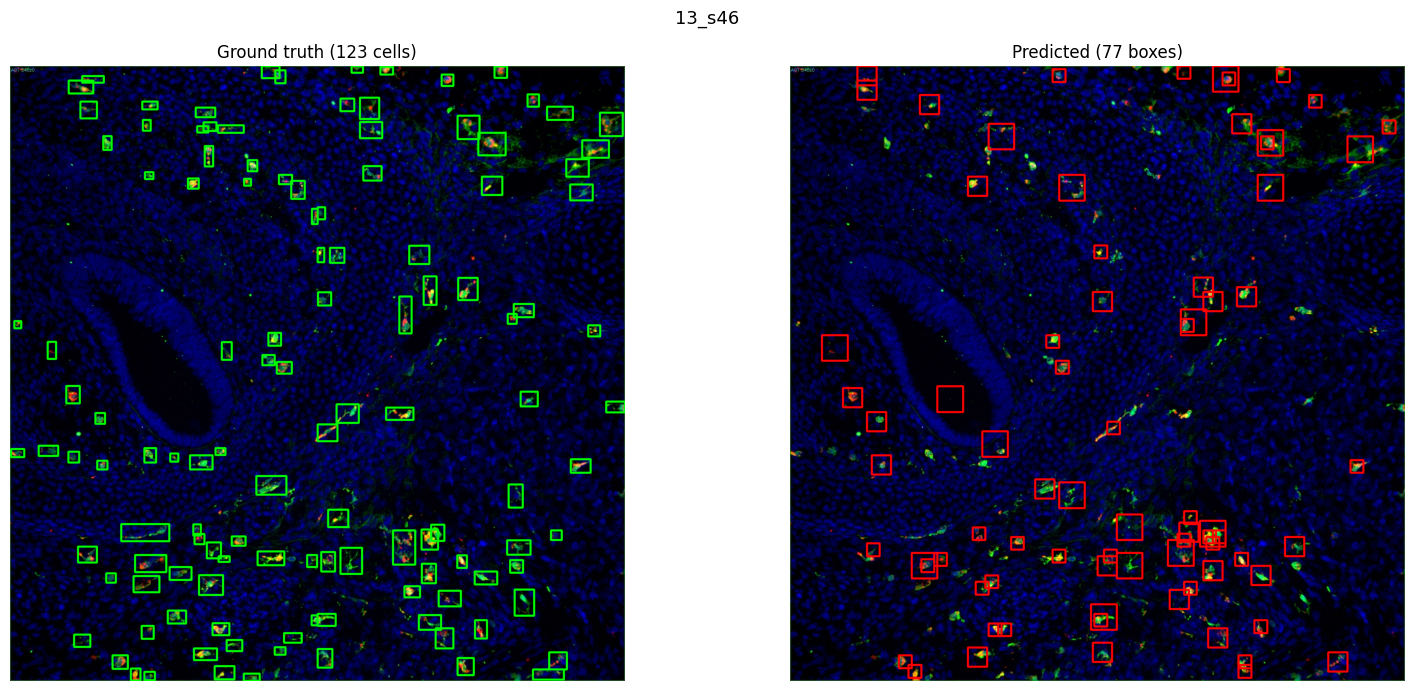


── 14_s47 ──
  scale=0.75 (1536×1536px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0%       9%      19%      29%      39%      48%      58%      68%      78%      88%      97% 100%
  → 36 candidates at this scale
  scale=1.00 (2048×2048px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0%       9%      19%      29%      38%      48%      58%      67%      77%      87%      96% 100%
  → 65 candidates at this scale
  scale=1.50 (3072×3072px)  

/home/ec2-user/lx-svm-venv/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


      0%       9%      19%      28%      38%      47%      57%      67%      76%      86%      95% 100%
  → 69 candidates at this scale

  Total candidates : 170
  After NMS        : 95
  Detection time: 291.2s
  GT=122  Pred=95  TP=27  FP=68  FN=95  Precision=0.28  Recall=0.22


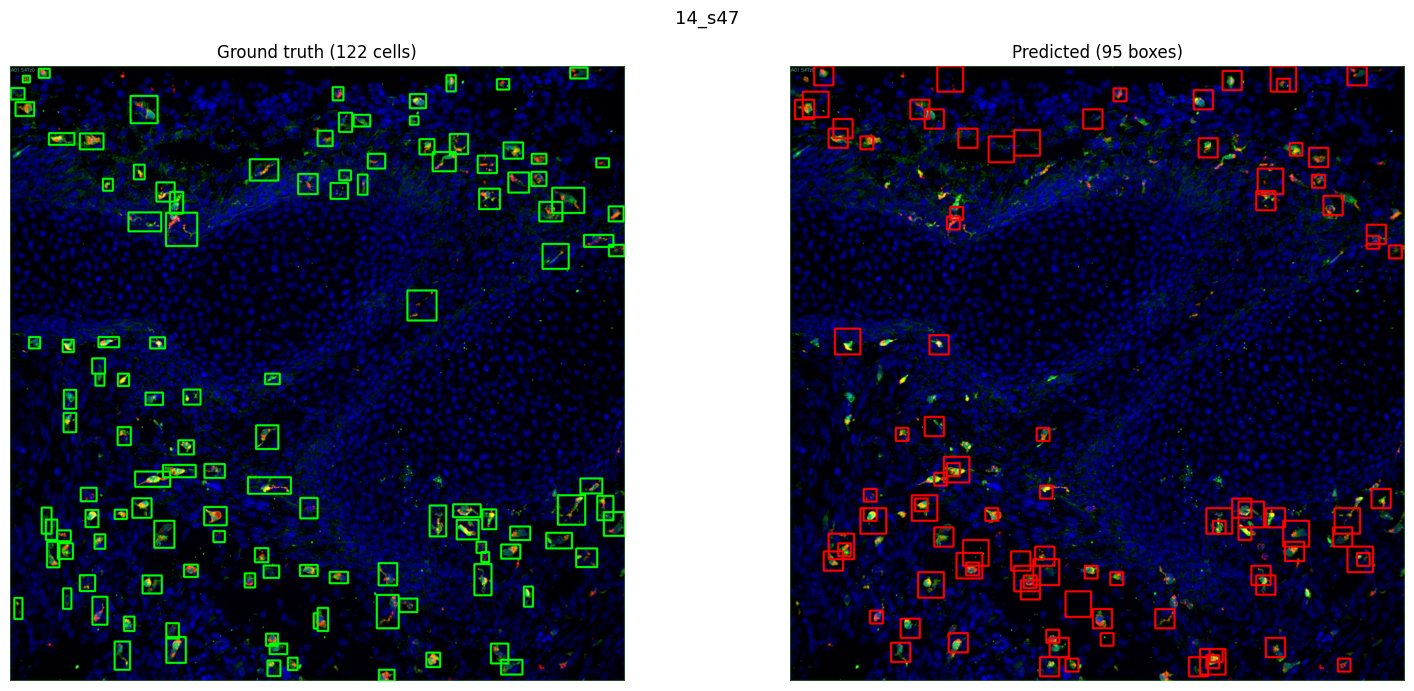

In [18]:
# ── Ensure test patches exist on disk ──────────────────────────────────────
# preprocess_all_images() is commented out in cell 10 (cold-start path), and
# features_cache.npz only stores train/val raw features. The test patch
# folders therefore stay empty until something extracts them. Idempotent —
# skipped once the folders are populated.
if not list_images(cfg.microglia_test_folder):
    print("Extracting test patches from test_dir/ ...")
    for path in list_images(cfg.test_dir):
        extract_patches_from_image(
            path, cfg.microglia_test_folder, cfg.noise_test_folder,
            cfg, augment=False,
        )
    n_pos = len(list_images(cfg.microglia_test_folder))
    n_neg = len(list_images(cfg.noise_test_folder))
    print(f"Extracted — microglia: {n_pos}, noise: {n_neg}\n")
    if n_pos == 0:
        raise RuntimeError(
            f"No test microglia patches extracted from {cfg.test_dir!r}. "
            f"Check that {cfg.image_rois_csv} has GT entries matching the "
            f"image stems (load_gt_boxes appends '.png' to the stem when "
            f"looking up rows)."
        )

# from tune_detection_threshold
cfg.detection_threshold=3.92
# ═══════════════════════════════════════════════════════════════════════════
# FINAL EVALUATION — HELD-OUT TEST SET
# Run this cell only once, after HNM is complete and threshold is tuned.
# ═══════════════════════════════════════════════════════════════════════════

# ── Patch-level evaluation ─────────────────────────────────────────────────
print("── Patch-level evaluation ──")
print("Extracting test patch features...")
test_pos_paths = list_images(cfg.microglia_test_folder)
test_neg_paths = list_images(cfg.noise_test_folder)
test_pos_feats = extract_features(test_pos_paths, cfg, label="test microglia")
test_neg_feats = extract_features(test_neg_paths, cfg, label="test noise")

X_test = np.vstack((test_pos_feats, test_neg_feats)).astype(np.float32)
y_test = np.hstack((np.ones(len(test_pos_feats)), np.zeros(len(test_neg_feats))))
X_test = scaler.transform(X_test)
if pca is not None:
    X_test = pca.transform(X_test)

evaluate_classifier(svm_clf, X_test, y_test, label="test")

# ── Detection-level evaluation ─────────────────────────────────────────────
print("\n── Detection-level evaluation ──")
final_test_paths = list_images(cfg.test_dir)
print(f"Running detection on {len(final_test_paths)} test images "
      f"at scales {cfg.scale_factors}, threshold={cfg.detection_threshold:.2f}\n")

for path in final_test_paths:
    stem = os.path.splitext(os.path.basename(path))[0]
    img  = mpimg.imread(path)

    print(f"── {stem} ──")
    t0 = time.time()
    result, boxes = process_image(img, svm_clf, scaler, cfg, pca=pca, show_stages=False)
    print(f"  Detection time: {time.time() - t0:.1f}s")

    gt_boxes = load_gt_boxes(stem, cfg.image_rois_csv)
    if gt_boxes:
        m = evaluate_detections(boxes, gt_boxes, iou_thresh=0.5)
        print(f"  GT={len(gt_boxes)}  Pred={len(boxes)}  "
              f"TP={m['tp']}  FP={m['fp']}  FN={m['fn']}  "
              f"Precision={m['precision']:.2f}  Recall={m['recall']:.2f}")
        plot_gt_vs_pred(img, boxes, gt_boxes, title=stem)
    else:
        print("  (no ground-truth annotations found in CSV)")
        plot_image(result, title=f"{stem} — {len(boxes)} cells detected")
    print()